# Demand Forecasting Prototype

This notebook is an **end-to-end prototype** that:

- creates synthetic sales, weather, and social signals
- performs ETL / feature engineering
- trains LightGBM and Prophet models
- ensembles forecasts and performs a simple backtest

> **How to run:** Install the requirements (see next cell), then run cells top-to-bottom in Jupyter or VS Code.


## 1) Install requirements
Run this cell once in a notebook environment (or install in your environment via pip):

In [5]:

# Uncomment and run if you need to install packages in the notebook environment.
# NOTE: prophet may be named 'prophet' or 'fbprophet' depending on environment; adjust accordingly.
!pip install pandas numpy matplotlib seaborn scikit-learn lightgbm prophet joblib
print('If needed, run: pip install pandas numpy matplotlib seaborn scikit-learn lightgbm prophet joblib')

If needed, run: pip install pandas numpy matplotlib seaborn scikit-learn lightgbm prophet joblib


## 2) Prepare the Sales and Weather and Social Events Data

In [6]:
import pandas as pd, numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
print('pandas', pd.__version__, 'numpy', np.__version__)

pandas 2.2.2 numpy 2.0.2


**Read Weather data**



In [7]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# --- CONFIG ---
API_KEY = "8280acd9e3982935ccf7b94299c92c47"
CITY_NAME = "OHIO"
LAT = 40.1088
LON = -82.9742
DAYS = 30

# ----------------------
# FETCH FUTURE FORECAST (OpenWeather)
# ----------------------
def fetch_forecast(city, api_key):
    url = "https://api.openweathermap.org/data/2.5/forecast"
    params = {
        "q": city,
        "appid": api_key,
        "units": "metric"
    }
    response = requests.get(url, params=params)
    data = response.json()

    if "list" not in data:
        raise Exception(f"Error fetching forecast: {data}")

    records = []
    for entry in data["list"]:
        dt = datetime.fromtimestamp(entry["dt"])
        records.append({
            "datetime": dt,
            "date": dt.date(),
            "temp_mean": entry["main"]["temp"],
            "humidity": entry["main"]["humidity"],
            "pressure": entry["main"]["pressure"],
            "weather": entry["weather"][0]["main"],
            "wind_speed": entry["wind"]["speed"],
            "precipitation": entry.get("rain", {}).get("3h", 0.0)
        })
    return pd.DataFrame(records)


df_future = fetch_forecast(CITY_NAME, API_KEY)

# ----------------------
# FETCH PAST HISTORY (Open-Meteo)
# ----------------------
END_DATE = datetime.today().date()
START_DATE = END_DATE - timedelta(days=DAYS)

url_hist = "https://archive-api.open-meteo.com/v1/archive"

params_hist = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": str(START_DATE),
    "end_date": str(END_DATE),
    "daily": [
        "temperature_2m_max",
        "temperature_2m_min",
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "surface_pressure_mean",
        "windspeed_10m_max",
        "precipitation_sum"
    ],
    "timezone": "America/New_York"
}

resp_hist = requests.get(url_hist, params=params_hist)
hist = resp_hist.json()

df_past = pd.DataFrame({
    "date": hist["daily"]["time"],
    "temp_max": hist["daily"]["temperature_2m_max"],
    "temp_min": hist["daily"]["temperature_2m_min"],
    "temp_mean": hist["daily"]["temperature_2m_mean"],
    "humidity": hist["daily"]["relative_humidity_2m_mean"],
    "pressure": hist["daily"]["surface_pressure_mean"],
    "wind_speed": hist["daily"]["windspeed_10m_max"],
    "precipitation": hist["daily"]["precipitation_sum"],
})

df_past["date"] = pd.to_datetime(df_past["date"]).dt.date
df_future["source"] = "future"
df_past["source"] = "past"

# ----------------------
# UNION THE DATA
# ----------------------
df_weather_history = pd.concat([df_past, df_future], ignore_index=True)

# Save final union dataset
df_weather_history.to_csv("weather_union_past_future.csv", index=False)
display(df_weather_history.head())


,date,temp_max,temp_min,temp_mean,humidity,pressure,wind_speed,precipitation,source,datetime,weather
0,2025-10-31,11.8,3.9,7.5,74,977.1,23.2,0.2,past,NaT,NaN
1,2025-11-01,13.0,4.0,7.7,74,984.5,10.9,0.0,past,NaT,NaN
2,2025-11-02,11.7,3.0,7.0,79,989.3,7.9,0.0,past,NaT,NaN
3,2025-11-03,13.3,3.7,7.6,74,988.2,21.9,0.0,past,NaT,NaN
4,2025-11-04,14.9,2.0,7.9,63,991.3,12.2,0.0,past,NaT,NaN


**Sales**: **Prodcts** & **Locations**

In [8]:
# Generate a larger synthetic dataset to meet the product/row requirements
np.random.seed(42)
start = pd.Timestamp('2025-11-01')
end = pd.Timestamp('2025-11-30')  # 100 days
dates_new = pd.date_range(start, end, freq='D')

# Define geographical coordinates for the locations
location_coordinates_data = {
    1: {'lat': 40.8037, 'lon': -80.9575},  # Warehouse North (sample Ohio location)
    2: {'lat': 39.5673, 'lon': -82.0911},  # Warehouse South (sample Ohio location)
    3: {'lat': 40.0805, 'lon': -84.3418},  # Warehouse West (sample Ohio location)
    4: {'lat': 40.4173, 'lon': -81.2330},  # Warehouse East (sample Ohio location)
    5: {'lat': 40.0000, 'lon': -83.0000},  # Warehouse Central (sample Ohio location near Columbus)
    6: {'lat': 39.9622, 'lon': -83.0007},  # Columbus Store A
    7: {'lat': 40.0264, 'lon': -82.9669},  # Columbus Store B
    8: {'lat': 39.8973, 'lon': -83.0769},  # Grove City Store A
    9: {'lat': 39.9202, 'lon': -83.1091}   # Grove City Store B
}

# More products
new_products = [{'product_id': i, 'sku':f'SKU-00{i}', 'name':f'Product {i}'} for i in range(1, 6)]
new_locations = [
    {'location_id': 1, 'location_name':'Warehouse North', 'latitude': location_coordinates_data[1]['lat'], 'longitude': location_coordinates_data[1]['lon']},
    {'location_id': 2, 'location_name':'Warehouse South', 'latitude': location_coordinates_data[2]['lat'], 'longitude': location_coordinates_data[2]['lon']},
    {'location_id': 3, 'location_name':'Warehouse West', 'latitude': location_coordinates_data[3]['lat'], 'longitude': location_coordinates_data[3]['lon']},
    {'location_id': 4, 'location_name':'Warehouse East', 'latitude': location_coordinates_data[4]['lat'], 'longitude': location_coordinates_data[4]['lon']},
    {'location_id': 5, 'location_name':'Warehouse Central', 'latitude': location_coordinates_data[5]['lat'], 'longitude': location_coordinates_data[5]['lon']},
    {'location_id': 6, 'location_name':'Columbus Store A', 'latitude': location_coordinates_data[6]['lat'], 'longitude': location_coordinates_data[6]['lon']},
    {'location_id': 7, 'location_name':'Columbus Store B', 'latitude': location_coordinates_data[7]['lat'], 'longitude': location_coordinates_data[7]['lon']},
    {'location_id': 8, 'location_name':'Grove City Store A', 'latitude': location_coordinates_data[8]['lat'], 'longitude': location_coordinates_data[8]['lon']},
    {'location_id': 9, 'location_name':'Grove City Store B', 'latitude': location_coordinates_data[9]['lat'], 'longitude': location_coordinates_data[9]['lon']}
]

product_location_rows = []
for p in new_products:
    for l in new_locations:
        baseline = np.random.randint(5, 20)  # varied base demand
        for i,d in enumerate(dates_new):
            sales = max(0, int(baseline + np.random.normal(0,5)))
            product_location_rows.append({
                'date': d, 'product_id': p['product_id'], 'sku': p['sku'], 'location_id': l['location_id'],
                'sales_qty': sales, 'latitude': l['latitude'], 'longitude': l['longitude']
            })
df_products_locations = pd.DataFrame(product_location_rows)

# Aggregate to store level and add available quantity
df_sales = df_products_locations.groupby(['product_id', 'location_id']).agg(
    total_products_sold=('sales_qty', 'sum'),
    latitude=('latitude', 'first'),
    longitude=('longitude', 'first')
).reset_index()

# Simulate available quantity (e.g., total_products_sold * random factor > 1)
df_sales['available_quantity'] = (df_sales['total_products_sold'] * np.random.uniform(1.1, 1.5, len(df_sales))).astype(int)

# Add total product counts (sold + available quantity)
df_sales['total_product_counts'] = df_sales['total_products_sold'] + df_sales['available_quantity']


print(f"Generated df_store_inventory with {len(df_sales)} rows and {df_sales['product_id'].nunique()} unique products.")
display(df_sales.head(100))

Generated df_store_inventory with 45 rows and 5 unique products.


,product_id,location_id,total_products_sold,latitude,longitude,available_quantity,total_product_counts
0,1,1,308,40.8037,-80.9575,433,741
1,1,2,205,39.5673,-82.0911,226,431
2,1,3,161,40.0805,-84.3418,203,364
3,1,4,146,40.4173,-81.2330,188,334
4,1,5,311,40.0000,-83.0000,344,655
5,1,6,228,39.9622,-83.0007,274,502
6,1,7,168,40.0264,-82.9669,235,403
7,1,8,342,39.8973,-83.0769,394,736
8,1,9,566,39.9202,-83.1091,743,1309
9,2,1,345,40.8037,-80.9575,409,754


**Social Media Trends**

In [125]:
import pandas as pd
import numpy as np

# Generate sample data for social media trends and events
social_media_data = {
    'date': pd.to_datetime(pd.date_range(start='2025-11-29', periods=10, freq='D')),
    'event_name': ['New Year Sale', 'Product Launch', 'Holiday Promo', 'Flash Sale', 'Social Media Challenge',
                   'No Event', 'No Event', 'Spring Collection', 'Influencer Collab', 'Weekend Deal'],
    'social_mentions': np.random.randint(50, 500, 10),
    'event_flag': [1, 1, 1, 1, 1, 0, 0, 1, 1, 1],
    'trend_score': np.random.randint(100, 1000, 10),
    'products_required': np.random.randint(1, 5, 10)
}

df_social_events = pd.DataFrame(social_media_data)

print("Sample df_social_events with 10 rows:")
display(df_social_events.head(100))

Sample df_social_events with 10 rows:


,date,event_name,social_mentions,event_flag,trend_score,products_required
0,2025-11-29,New Year Sale,280,1,528,3
1,2025-11-30,Product Launch,257,1,973,2
2,2025-12-01,Holiday Promo,124,1,821,1
3,2025-12-02,Flash Sale,319,1,354,4
4,2025-12-03,Social Media Challenge,436,1,631,4
5,2025-12-04,No Event,163,0,669,1
6,2025-12-05,No Event,111,0,211,4
7,2025-12-06,Spring Collection,411,1,412,4
8,2025-12-07,Influencer Collab,369,1,560,2
9,2025-12-08,Weekend Deal,151,1,807,4


## 3) Create synthetic dataset: sales, weather, social signals, events

In [2]:
print("Final Combined Dataset (panel) head for dynamic inventory allocation:")

# ----------------------- WEATHER (Open-Meteo daily already) -----------------------
if 'df_weather_history' in locals():
    df_weather_daily = df_weather_history.copy()
else:
    print("Warning: df_weather_history not found.")
    df_weather_daily = pd.DataFrame(columns=[
        'date','temp_min','temp_max','temp_mean','humidity',
        'pressure','wind_speed','precipitation'
    ])

# Ensure correct date format
df_weather_daily['date'] = pd.to_datetime(df_weather_daily['date']).dt.date

display(df_weather_daily.head())

# ----------------------- SOCIAL EVENTS -----------------------
if 'df_social_events' not in locals():
    print("Warning: df_social_events not found.")
    df_social_events = pd.DataFrame(columns=[
        'date','event_name','social_mentions','event_flag','trend_score','products_required'
    ])

df_social_events['date'] = pd.to_datetime(df_social_events['date']).dt.date

display(df_social_events.head())


# ----------------------- SALES DATA -----------------------
if 'df_sales' not in locals():
    raise ValueError("df_sales not found — load df_sales before merging.")

if 'date' not in df_sales.columns:
    df_sales = df_sales.copy()
    df_sales['date'] = pd.date_range(start='2025-11-30', periods=len(df_sales), freq='D')
    df_sales['date'] = pd.to_datetime(df_sales['date']).dt.date

df_sales['date'] = pd.to_datetime(df_sales['date']).dt.date
display(df_sales.head())

# ----------------------- MERGE ALL -----------------------
df_final_combined_raw = (
    df_sales
    .merge(df_weather_daily, on='date', how='left')
    .merge(df_social_events, on='date', how='left')
)

# ----------------------- FILL MISSING VALUES -----------------------

# Social
df_final_combined_raw['social_mentions'] = df_final_combined_raw['social_mentions'].fillna(0)
df_final_combined_raw['event_flag'] = df_final_combined_raw['event_flag'].fillna(0).astype(int)
df_final_combined_raw['trend_score'] = df_final_combined_raw['trend_score'].fillna(0)
df_final_combined_raw['products_required'] = df_final_combined_raw['products_required'].fillna(0)
df_final_combined_raw['event_name'] = df_final_combined_raw['event_name'].fillna('')


# Weather columns from Open-Meteo
weather_cols = [
    'temp_min', 'temp_max', 'temp_mean',
    'humidity', 'pressure', 'wind_speed', 'precipitation'
]

for col in weather_cols:
    df_final_combined_raw[col] = (
        df_final_combined_raw
        .groupby(['product_id', 'location_id'])[col]
        .transform(lambda x: x.ffill().bfill())
    )
    df_final_combined_raw[col] = df_final_combined_raw[col].fillna(df_final_combined_raw[col].mean())


print("Final combined raw dataset for dynamic inventory allocation:")
display(df_final_combined_raw.head())


Final Combined Dataset (panel) head for dynamic inventory allocation:


NameError: name 'pd' is not defined

## 4) ETL / Feature engineering: lags, rolling means, time features

In [158]:
import pandas as pd
import numpy as np

# ----------------------------
# Copy & Normalize Data
# ----------------------------
df = df_final_combined_raw.copy()

# Ensure date/datetime columns
df['date'] = pd.to_datetime(df['date'])
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Sort for time series operations
df = df.sort_values(['product_id', 'location_id', 'date']).reset_index(drop=True)

# ----------------------------
# Daily Aggregation
# ----------------------------
agg_dict = {
    # Sales
    'total_products_sold': 'sum',
    # Inventory
    'latitude': 'first',
    'longitude': 'first',
    'available_quantity': 'first',
    'total_product_counts': 'first',
    # Weather
    'temp_max': 'mean',
    'temp_min': 'mean',
    'humidity': 'mean',
    'pressure': 'mean',
    'wind_speed': 'mean',
    'precipitation': 'sum',
    # Events / Social
    'event_name': 'first',
    'social_mentions': 'sum',
    'event_flag': 'max',
    'trend_score': 'mean',
    'products_required': 'mean'
}

# Add temp_mean if exists
if 'temp_mean' in df.columns:
    agg_dict['temp_mean'] = 'mean'

# Add weather mode
agg_dict['weather'] = lambda x: x.mode()[0] if len(x.mode()) else None

# Source: past/future
agg_dict['source'] = lambda x: "future" if "future" in x.values else "past"

daily = df.groupby(['product_id', 'location_id', 'date'], as_index=False).agg(agg_dict)

# ----------------------------
# Create Complete Panel
# ----------------------------
skus = daily['product_id'].unique()
locs = daily['location_id'].unique()
date_index = pd.date_range(daily['date'].min(), daily['date'].max())

panel = (
    pd.MultiIndex.from_product([skus, locs, date_index], names=['product_id', 'location_id', 'date'])
    .to_frame(index=False)
)

panel = panel.merge(daily, on=['product_id', 'location_id', 'date'], how='left')

# ----------------------------
# Fill Missing Values
# ----------------------------
num_fill_zero = ['total_products_sold', 'social_mentions', 'event_flag',
                 'precipitation', 'trend_score', 'products_required']

str_fill_empty = ['event_name', 'weather', 'source']

weather_numeric = ['temp_max', 'temp_min', 'temp_mean', 'humidity', 'pressure', 'wind_speed']

for col in num_fill_zero:
    if col in panel.columns:
        panel[col] = panel[col].fillna(0)

for col in str_fill_empty:
    if col in panel.columns:
        panel[col] = panel[col].fillna("")

for col in weather_numeric:
    if col in panel.columns:
        panel[col] = panel[col].astype(float)

# ----------------------------
# Forward/Backward Fill Weather
# ----------------------------
for col in weather_numeric:
    if col in panel.columns:
        panel[col] = (
            panel.groupby(['product_id', 'location_id'])[col]
                 .apply(lambda s: s.ffill().bfill().fillna(s.mean()))
                 .reset_index(level=[0, 1], drop=True)
        )

# ----------------------------
# Time Features
# ----------------------------
panel['dow'] = panel['date'].dt.dayofweek
panel['month'] = panel['date'].dt.month
panel['is_weekend'] = panel['dow'].isin([5, 6]).astype(int)

# ----------------------------
# Lag Features & Rolling Windows
# ----------------------------
panel = panel.sort_values(['product_id', 'location_id', 'date'])
grouped = panel.groupby(['product_id', 'location_id'])['total_products_sold']

# Lags
for lag in [1, 7, 14, 28]:
    panel[f'sales_lag_{lag}'] = grouped.shift(lag).fillna(0)

# Rolling Means
panel['roll7_mean'] = grouped.shift(1).rolling(7).mean().fillna(0)
panel['roll28_mean'] = grouped.shift(1).rolling(28).mean().fillna(0)

# ----------------------------
# Target
# ----------------------------
panel['target'] = panel['total_products_sold']

# ----------------------------
# Display Final Panel
# ----------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
display(panel.head(20))


,product_id,location_id,date,total_products_sold,latitude,longitude,available_quantity,total_product_counts,temp_max,temp_min,humidity,pressure,wind_speed,precipitation,event_name,social_mentions,event_flag,trend_score,products_required,temp_mean,weather,source,dow,month,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,roll7_mean,roll28_mean,target
0,1,1,2025-11-30,2464.0,40.8037,-80.9575,433.0,741.0,3.9,-2.3,81.375,1015.5125,11.46,1.05,Product Launch,2056.0,1.0,973.0,2.0,0.16125,Snow,future,6,11,1,0.0,0.0,0.0,0.0,0.0,0.0,2464.0
1,1,1,2025-12-01,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,0,12,0,2464.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,2025-12-02,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,1,12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,2025-12-03,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,2,12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,1,2025-12-04,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,3,12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1,1,2025-12-05,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,4,12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,1,2025-12-06,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,5,12,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1,1,2025-12-07,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,6,12,1,0.0,2464.0,0.0,0.0,352.0,0.0,0.0
8,1,1,2025-12-08,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,0,12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1,1,2025-12-09,0.0,NaN,NaN,NaN,NaN,3.9,-2.3,81.375,1015.5125,11.46,0.00,,0.0,0.0,0.0,0.0,0.16125,,,1,12,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5) Quick visualization of sales + social signal for a product-location

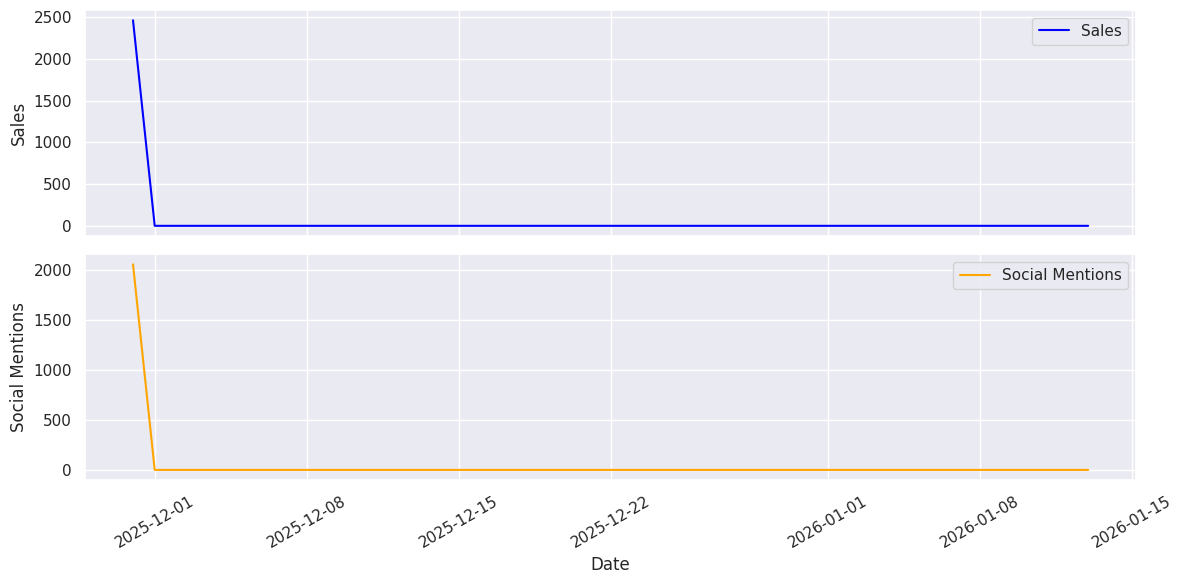

In [160]:
import matplotlib.pyplot as plt

# ----------------------------
# Select product 1, location 1
# ----------------------------
sel = panel[(panel['product_id'] == 1) & (panel['location_id'] == 1)].copy()

# ----------------------------
# Plot sales and social_mentions
# ----------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Sales plot
ax[0].plot(sel['date'], sel['total_products_sold'], label='Sales', color='blue')
ax[0].set_ylabel('Sales')
ax[0].legend()
ax[0].grid(True)

# Social mentions plot
ax[1].plot(sel['date'], sel['social_mentions'], label='Social Mentions', color='orange')
ax[1].set_ylabel('Social Mentions')
ax[1].legend()
ax[1].grid(True)

# X-axis formatting
plt.xticks(rotation=30)
plt.xlabel('Date')
plt.tight_layout()
plt.show()


## 6) Train / Test split (time-based)

In [161]:
# ----------------------------
# Ensure 'date' column is datetime
# ----------------------------
panel['date'] = pd.to_datetime(panel['date'])

# ----------------------------
# Define train/test split (last 14 days as test)
# ----------------------------
split_date = panel['date'].max() - pd.Timedelta(days=14)

train = panel[panel['date'] <= split_date].copy()
test = panel[panel['date'] > split_date].copy()

# ----------------------------
# Display info
# ----------------------------
print(f"Train shape: {train.shape}, Date range: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test shape: {test.shape}, Date range: {test['date'].min().date()} to {test['date'].max().date()}")


Train shape: (1395, 32), Date range: 2025-11-30 to 2025-12-30
Test shape: (630, 32), Date range: 2025-12-31 to 2026-01-13


## 7) Train LightGBM (feature-rich regressor)

In [164]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# ----------------------------
# Features for the model
# ----------------------------
features = [
    'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'social_mentions', 'event_flag',
    'dow', 'is_weekend', 'month',
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'roll7_mean', 'roll28_mean'
]

# Ensure all features exist in the panel
features = [f for f in features if f in panel.columns]

# ----------------------------
# Prepare training/testing matrices
# ----------------------------
X_train = train[features].fillna(0)
y_train = train['target'].values
X_test = test[features].fillna(0)
y_test = test['target'].values

# ----------------------------
# LightGBM dataset
# ----------------------------
dtrain = lgb.Dataset(X_train, label=y_train)

# ----------------------------
# LightGBM parameters
# ----------------------------
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

# ----------------------------
# Train the model
# ----------------------------
lgb_model = lgb.train(
    params,
    dtrain,
    num_boost_round=200
)

# ----------------------------
# Predict and evaluate
# ----------------------------
pred_lgb = lgb_model.predict(X_test)

mae = mean_absolute_error(y_test, pred_lgb)
mape = mean_absolute_percentage_error(y_test, pred_lgb)

print(f"LGB MAE: {mae:.4f}, MAPE: {mape:.4f}")


LGB MAE: 17.8745, MAPE: 66465831434224368.0000


## 8) Prophet (trend + seasonality) for top SKU-locations

In [166]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import pandas as pd
import numpy as np

# ----------------------------
# Features for modeling
# ----------------------------
features = [
    'temp_max', 'temp_min', 'temp_mean', 'precipitation', 'social_mentions', 'event_flag',
    'dow', 'is_weekend', 'month',
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'roll7_mean', 'roll28_mean'
]

# Ensure all features exist
features = [f for f in features if f in panel.columns]

# ----------------------------
# Parameters
# ----------------------------
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1
}

num_boost_round = 200
test_days = 14  # Last 14 days as test

# ----------------------------
# Prepare to store results
# ----------------------------
predictions_list = []
metrics_list = []

# ----------------------------
# Loop over all product × location
# ----------------------------
for (prod, loc), group in panel.groupby(['product_id', 'location_id']):

    group = group.sort_values('date').copy()

    # Train/test split (last 14 days for test)
    split_date = group['date'].max() - pd.Timedelta(days=test_days)
    train = group[group['date'] <= split_date].copy()
    test = group[group['date'] > split_date].copy()

    # Skip if not enough data
    if len(train) < 1 or len(test) < 1:
        continue

    X_train = train[features].fillna(0)
    y_train = train['target'].values
    X_test = test[features].fillna(0)
    y_test = test['target'].values

    # LightGBM dataset
    dtrain = lgb.Dataset(X_train, label=y_train)

    # Train model
    model = lgb.train(params, dtrain, num_boost_round=num_boost_round)

    # Predict
    pred = model.predict(X_test)

    # Store predictions with product/location/date
    pred_df = pd.DataFrame({
        'product_id': prod,
        'location_id': loc,
        'date': test['date'],
        'actual': y_test,
        'predicted': pred
    })
    predictions_list.append(pred_df)

    # Compute metrics
    mae = mean_absolute_error(y_test, pred)
    mape = mean_absolute_percentage_error(y_test, pred)
    metrics_list.append({'product_id': prod, 'location_id': loc, 'MAE': mae, 'MAPE': mape})

# ----------------------------
# Combine results
# ----------------------------
predictions = pd.concat(predictions_list, ignore_index=True)
metrics = pd.DataFrame(metrics_list)

# ----------------------------
# Display summary
# ----------------------------
print("Predictions sample:")
display(predictions.head(10))

print("Metrics summary:")
display(metrics.sort_values('MAE'))


Predictions sample:


,product_id,location_id,date,actual,predicted
0,1,1,2025-12-31,0.0,79.483871
1,1,1,2026-01-01,0.0,79.483871
2,1,1,2026-01-02,0.0,79.483871
3,1,1,2026-01-03,0.0,79.483871
4,1,1,2026-01-04,0.0,79.483871
5,1,1,2026-01-05,0.0,79.483871
6,1,1,2026-01-06,0.0,79.483871
7,1,1,2026-01-07,0.0,79.483871
8,1,1,2026-01-08,0.0,79.483871
9,1,1,2026-01-09,0.0,79.483871


Metrics summary:


,product_id,location_id,MAE,MAPE
6,1,7,5.419355,2.440660e+16
11,2,3,5.580645,2.513299e+16
20,3,3,5.677419,2.556882e+16
21,3,4,6.161290,2.774798e+16
29,4,3,6.741935,3.036298e+16
5,1,6,7.354839,3.312325e+16
18,3,1,9.354839,4.213045e+16
30,4,4,9.516129,4.285684e+16
14,2,6,9.806452,4.416433e+16
24,3,7,10.258065,4.619822e+16


LGB visualization

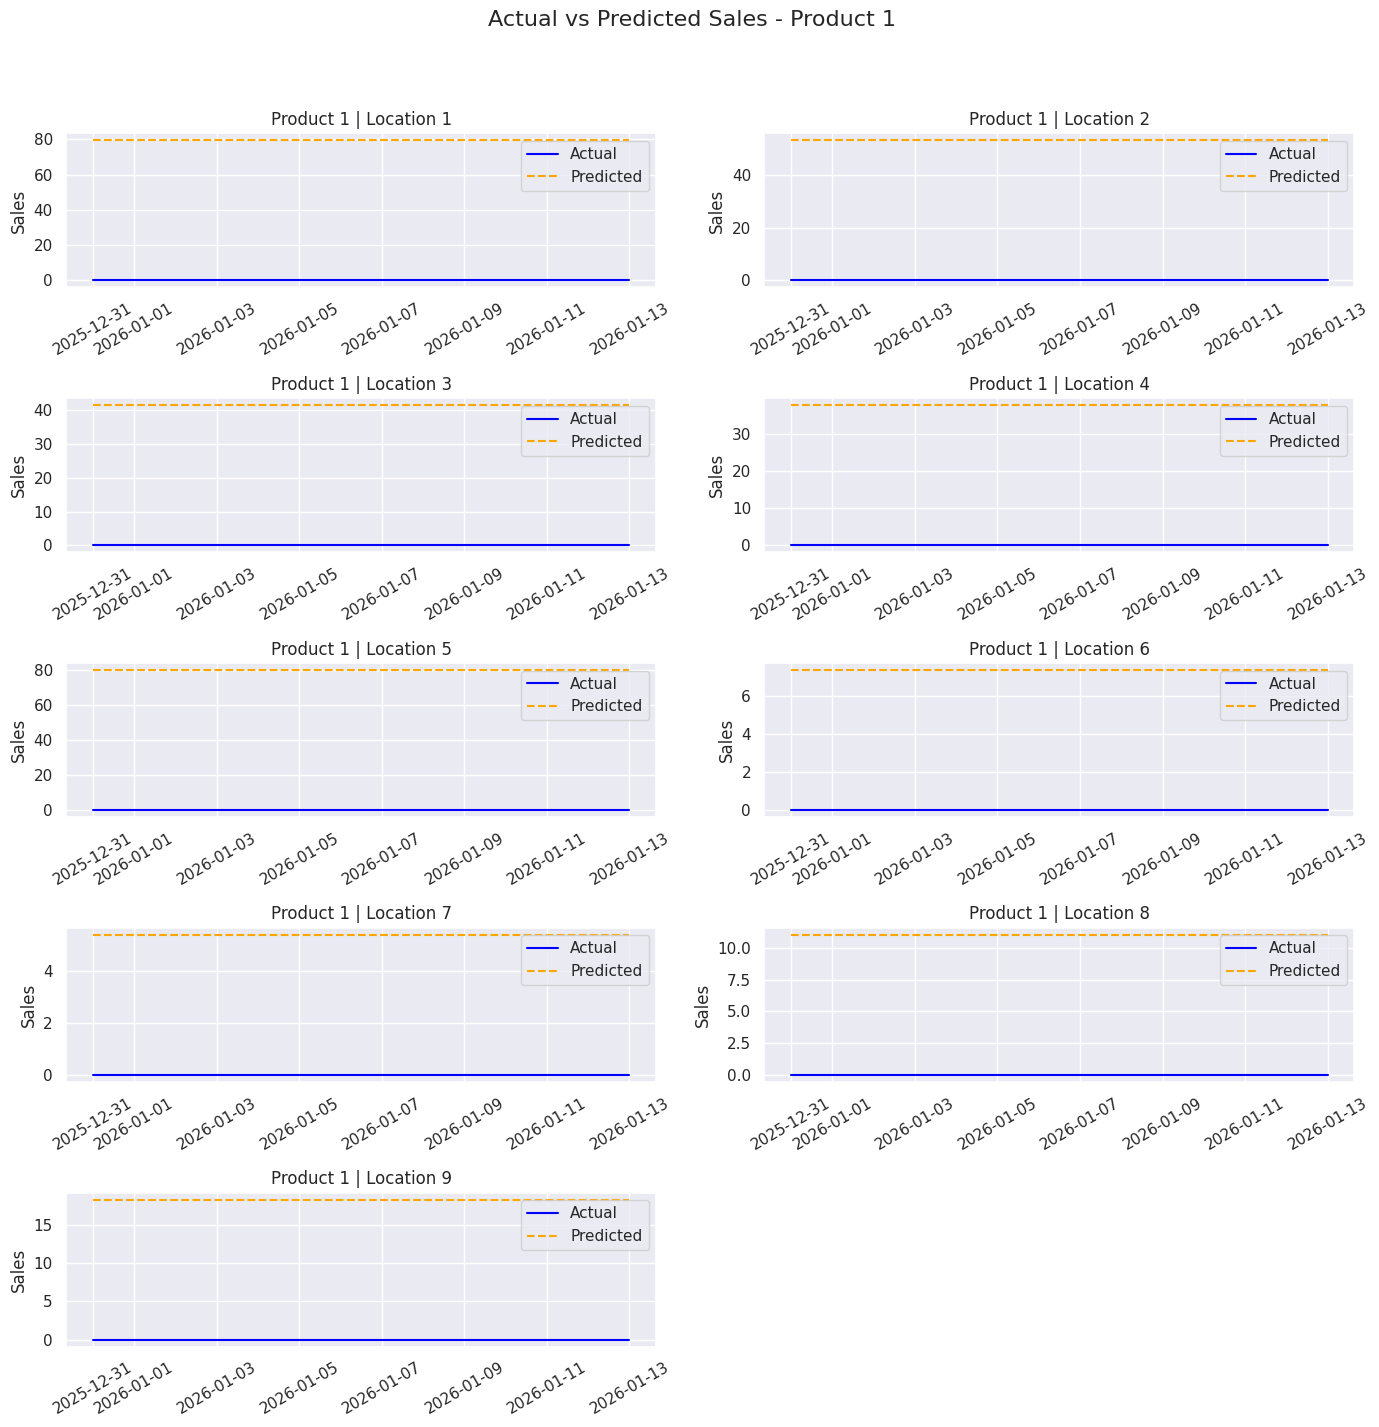

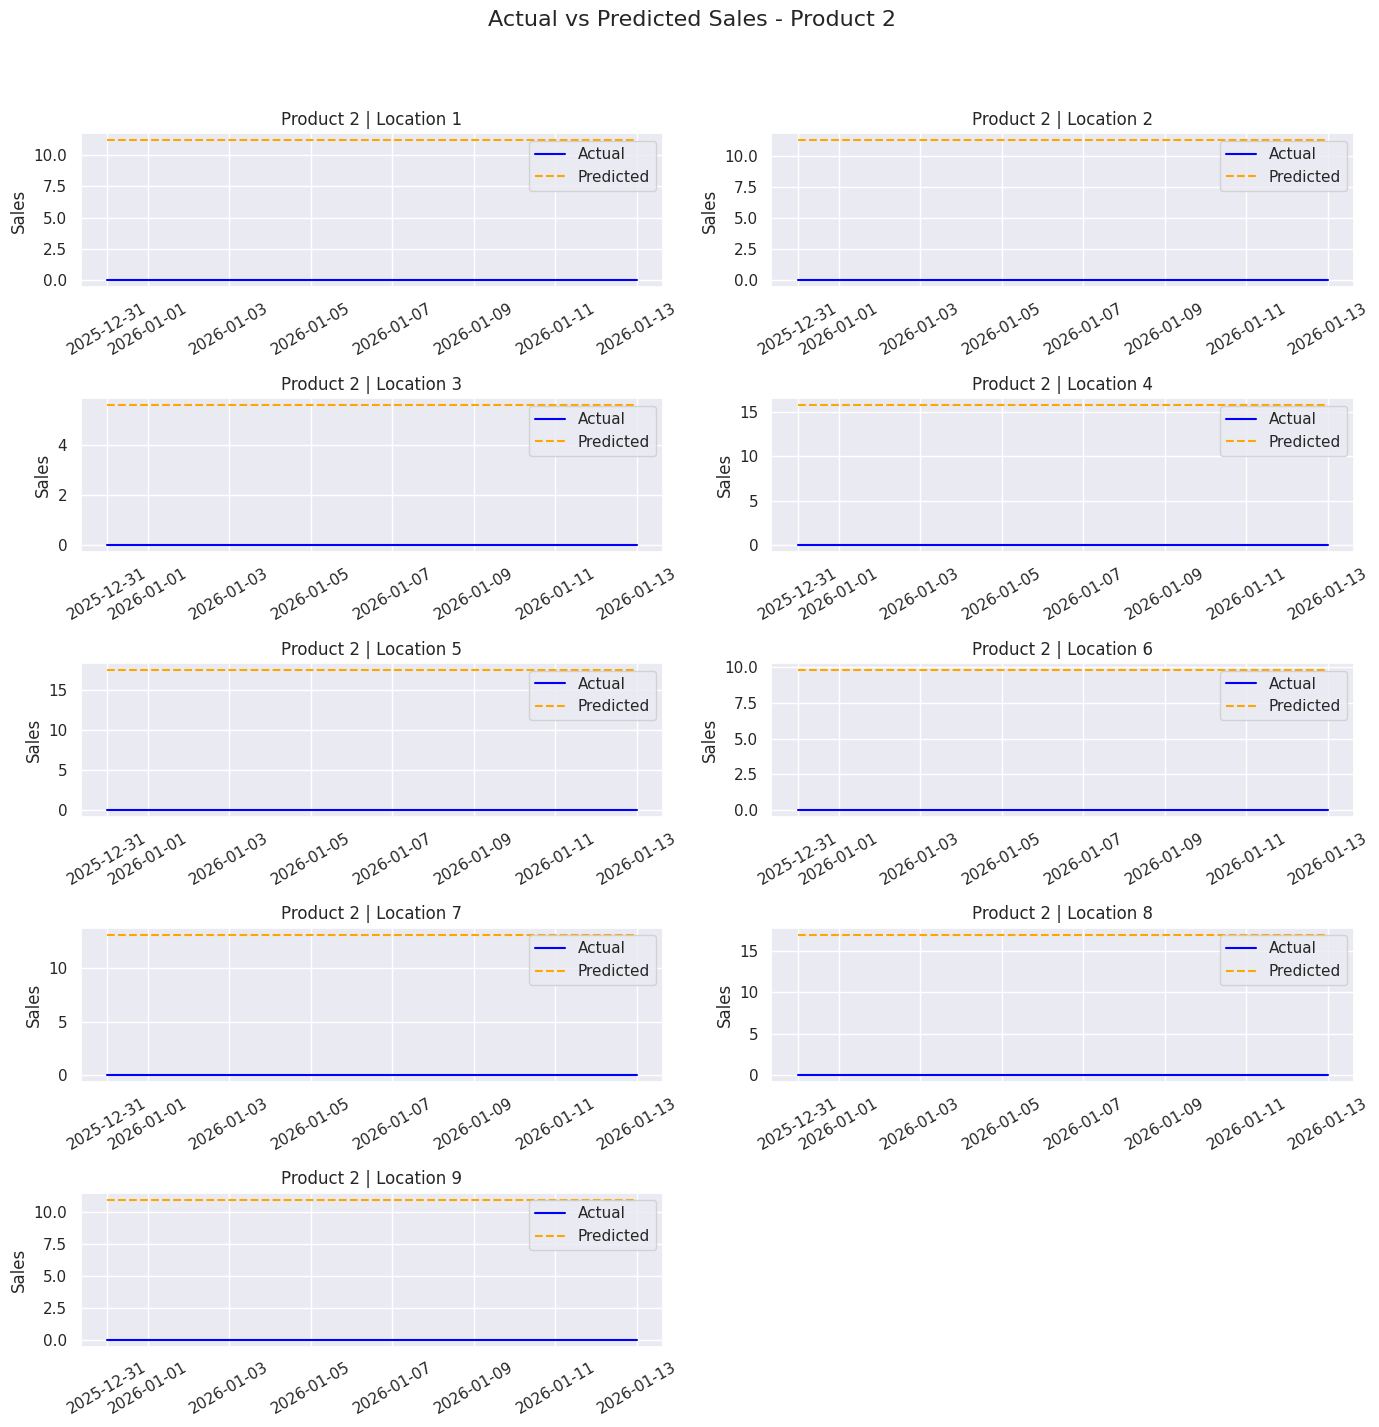

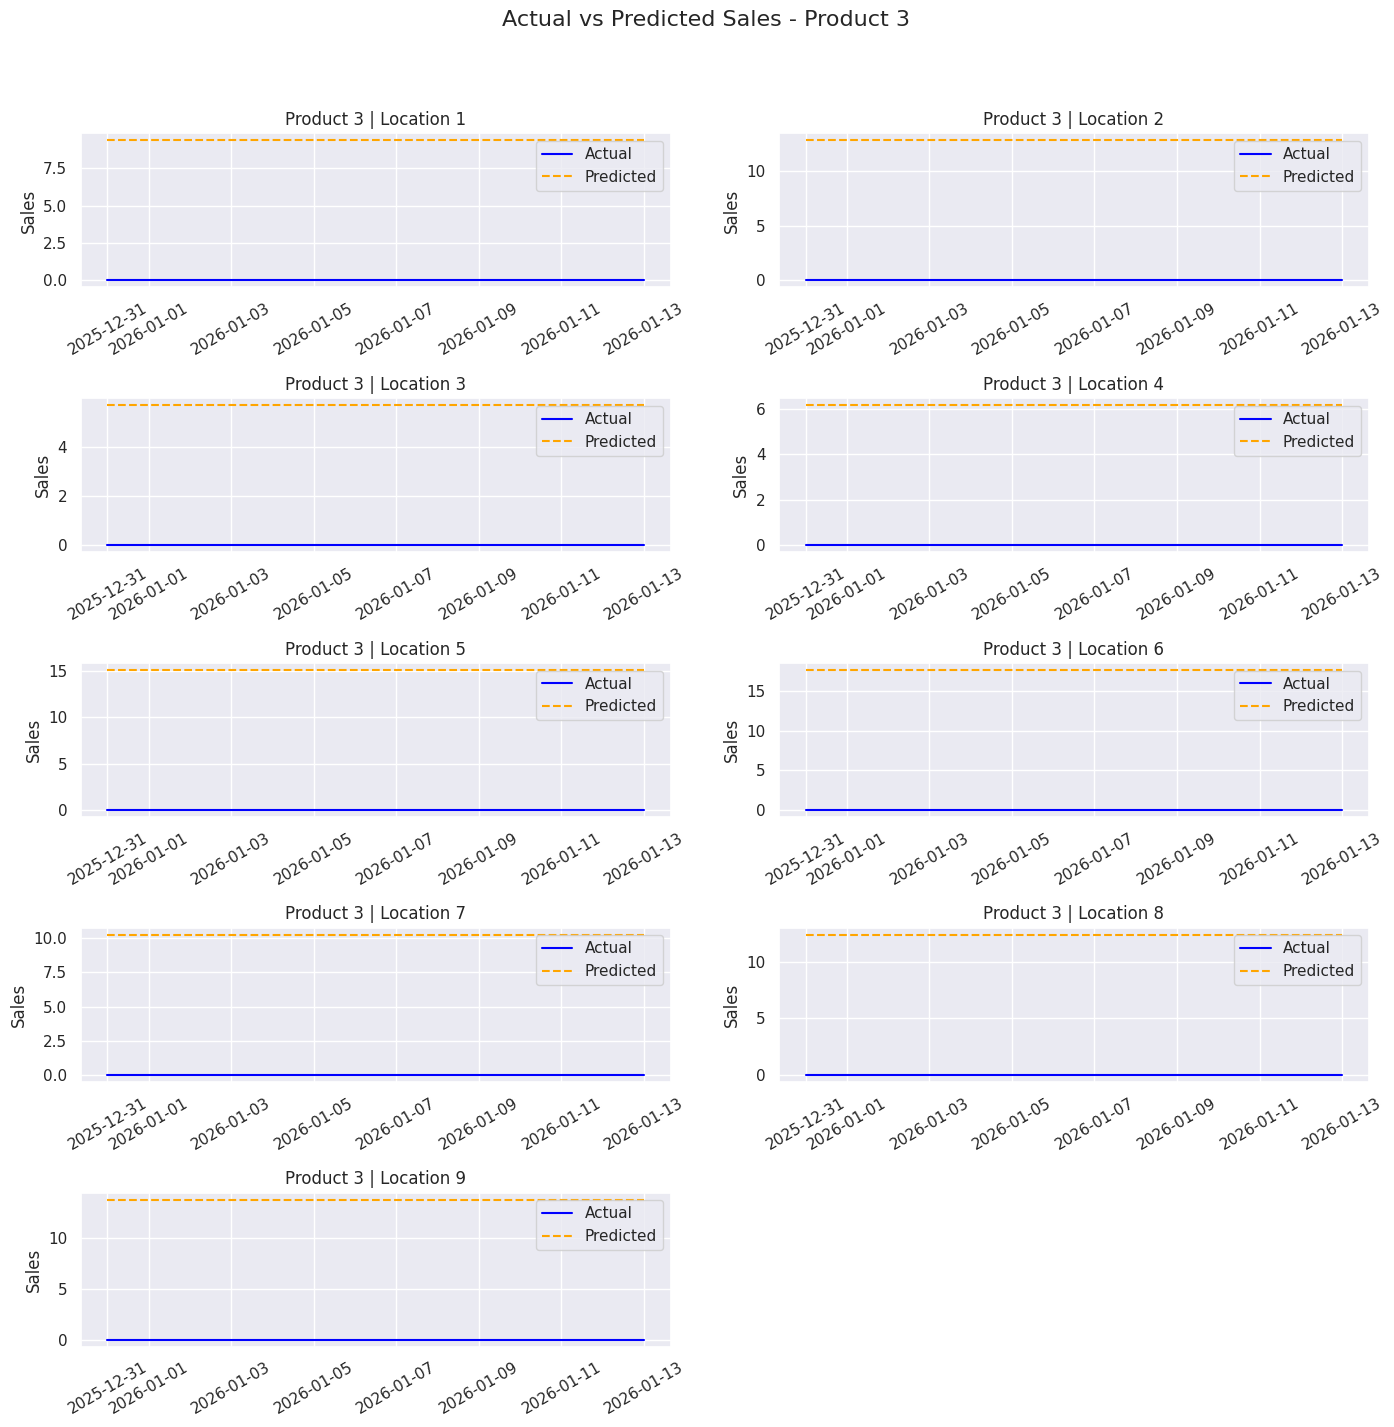

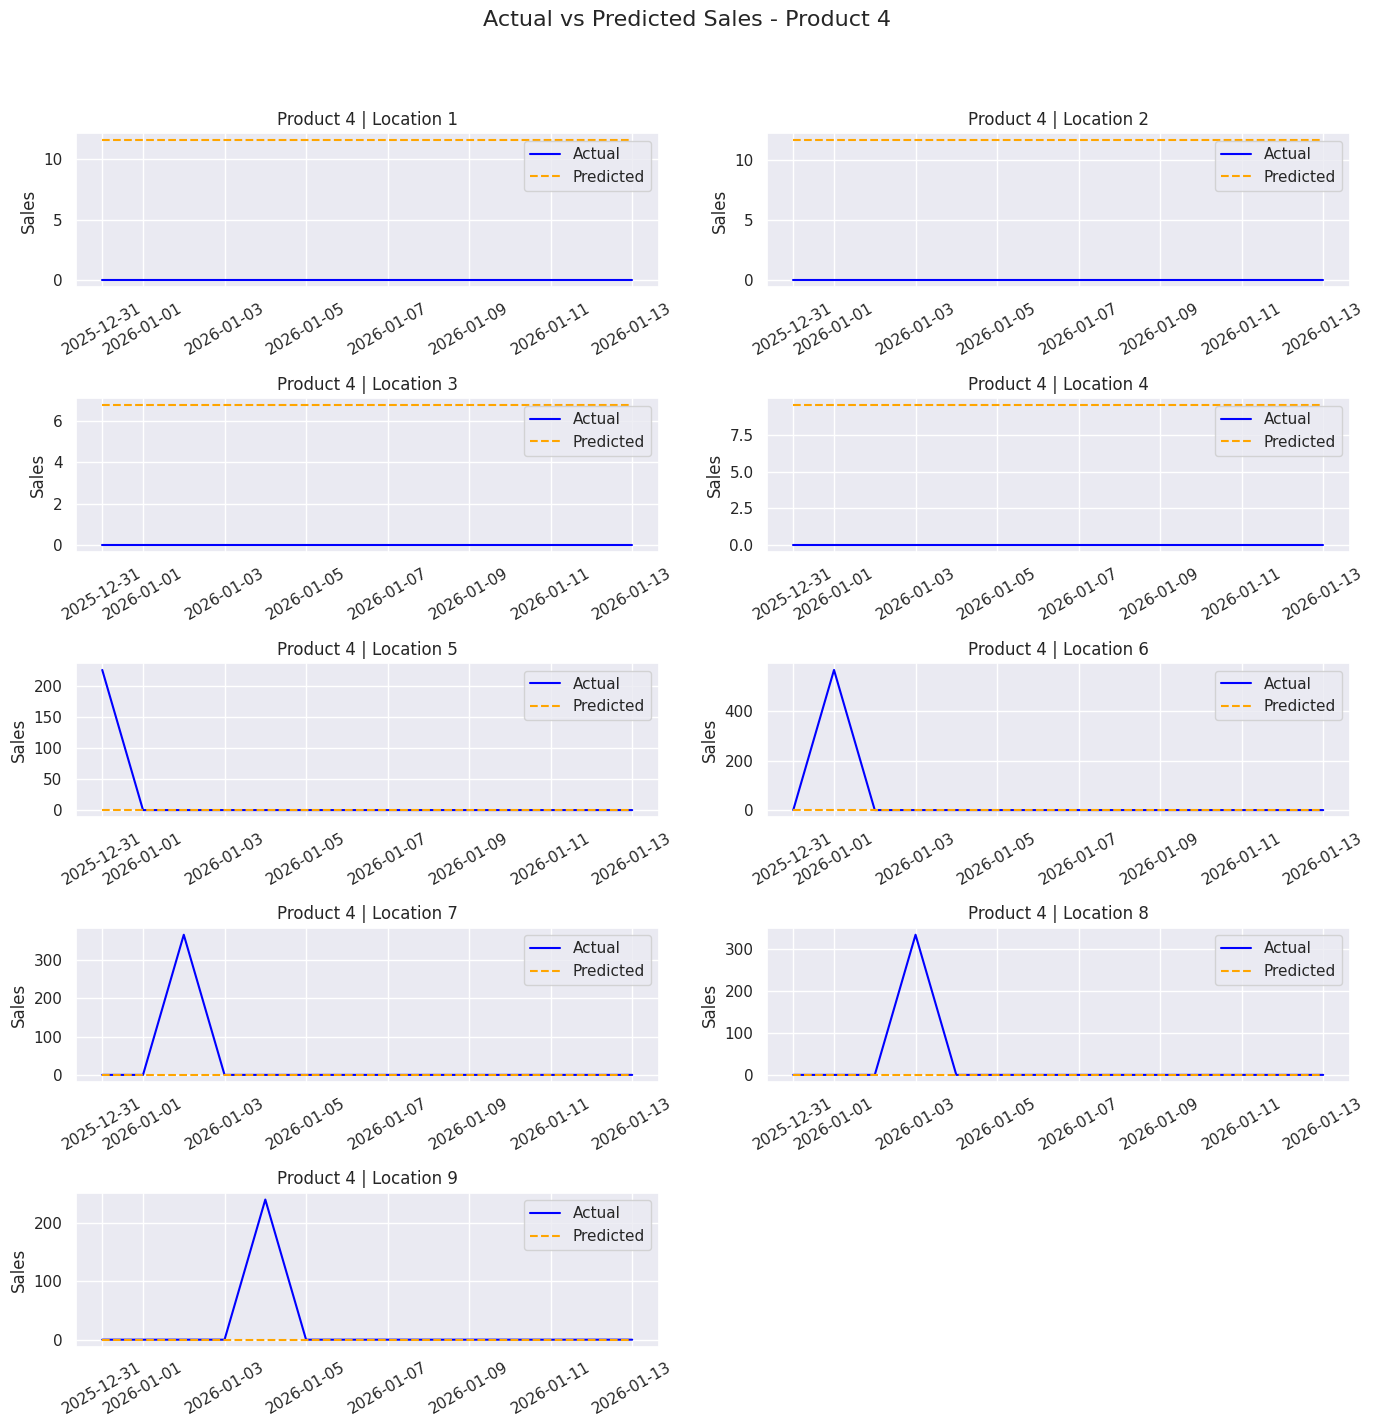

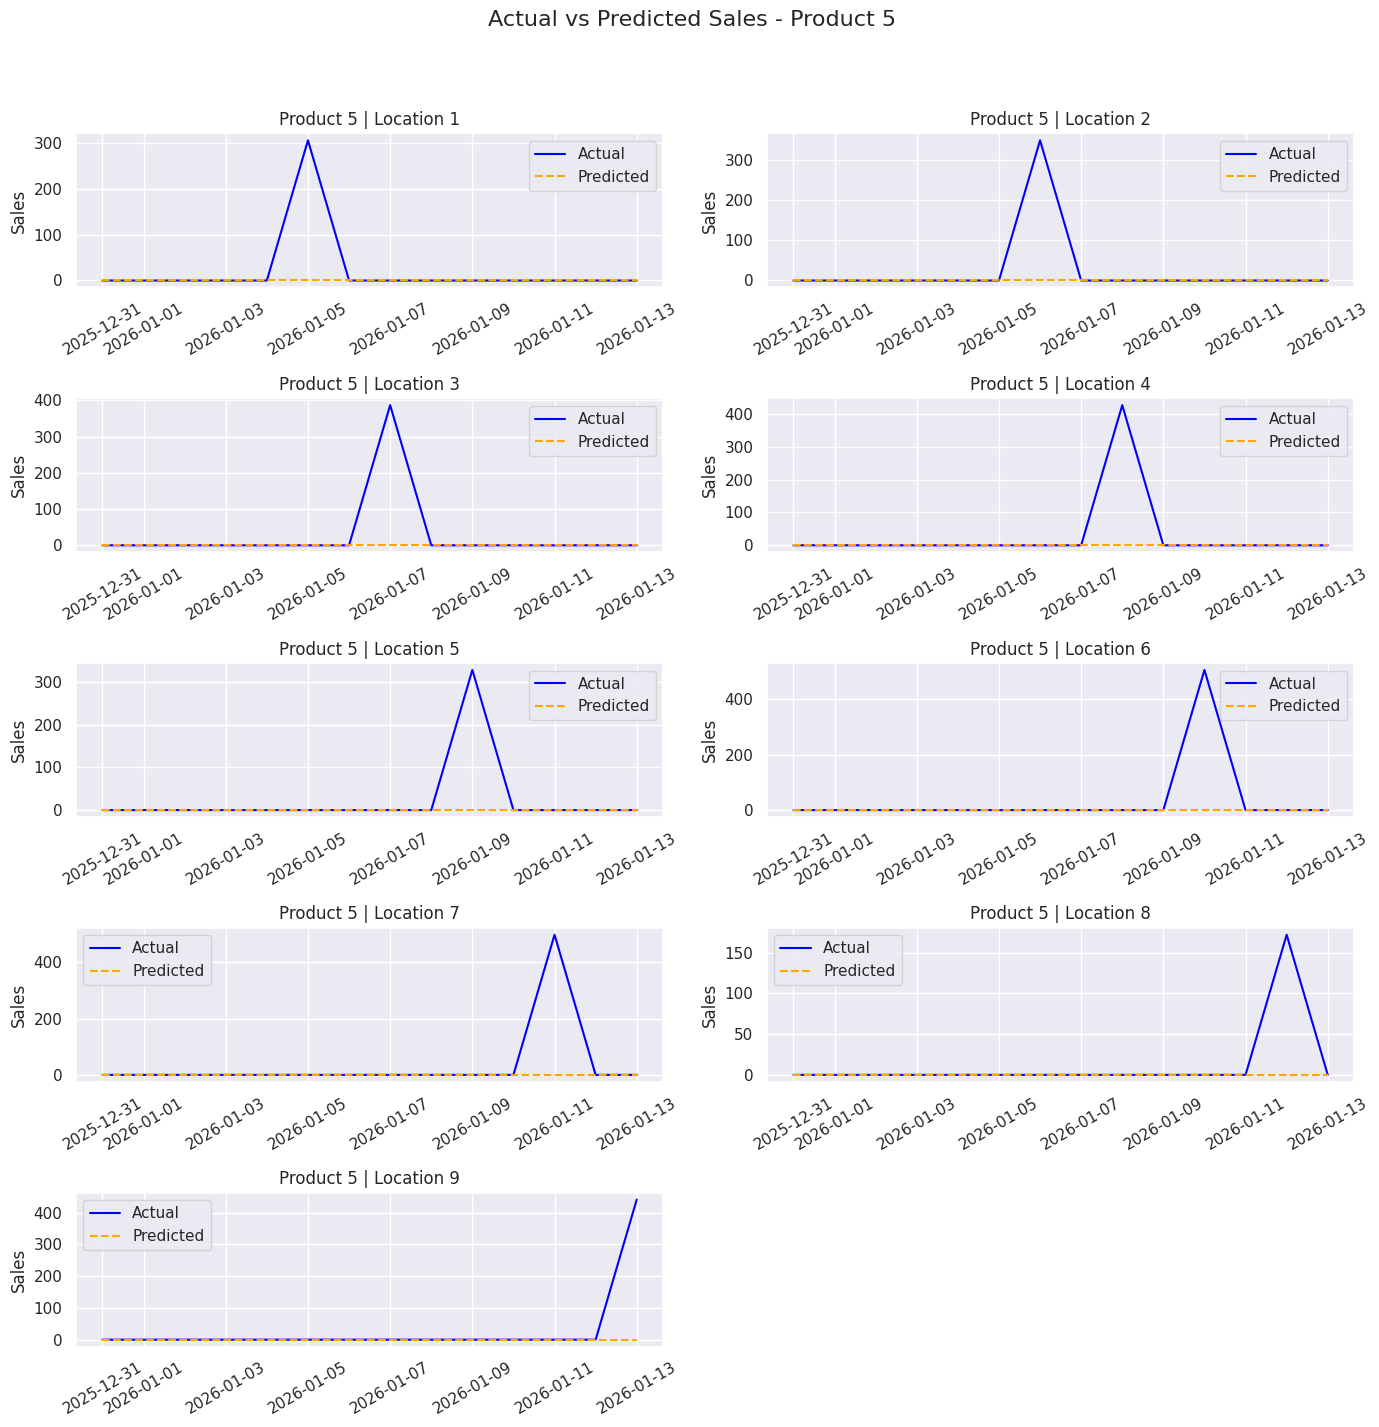

In [170]:
import matplotlib.pyplot as plt
import math

# ----------------------------
# Loop over each product
# ----------------------------
for product_id, prod_group in predictions.groupby('product_id'):

    locations = prod_group['location_id'].unique()
    n_locs = len(locations)

    # Determine subplot grid
    ncols = 2
    nrows = math.ceil(n_locs / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3), sharex=False)
    axes = axes.flatten()  # flatten in case of 1 row or column

    # ----------------------------
    # Plot each location for this product
    # ----------------------------
    for i, loc in enumerate(locations):
        sel = prod_group[prod_group['location_id']==loc]

        axes[i].plot(sel['date'], sel['actual'], label='Actual', color='blue')
        axes[i].plot(sel['date'], sel['predicted'], label='Predicted', color='orange', linestyle='--')

        axes[i].set_title(f'Product {product_id} | Location {loc}')
        axes[i].set_ylabel('Sales')
        axes[i].legend()
        axes[i].grid(True)
        axes[i].tick_params(axis='x', rotation=30)

    # Hide unused subplots if any
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Actual vs Predicted Sales - Product {product_id}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## 9) Prophet predictions on test period (where model exists)

In [175]:
import pandas as pd

# ----------------------------
# Ensure columns exist
# ----------------------------
if 'predicted' not in test.columns:
    test['predicted'] = None  # fill with None if missing

if 'pred_prophet' not in test.columns:
    test['pred_prophet'] = None  # fill with None if missing

# ----------------------------
# Columns to display
# ----------------------------
columns_to_show = ['date', 'product_id', 'location_id', 'target', 'predicted', 'pred_prophet']

# Filter only existing columns (safeguard)
columns_to_show = [col for col in columns_to_show if col in test.columns]

# ----------------------------
# Display first few rows
# ----------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

print("Sample of test predictions:")
display(test[columns_to_show].head(20))

# ----------------------------
# Summary statistics
# ----------------------------
print("\nSummary statistics for predictions:")
display(test[columns_to_show].describe())


Sample of test predictions:


,date,product_id,location_id,target,predicted,pred_prophet
2011,2025-12-31,5,9,0.0,None,0.0
2012,2026-01-01,5,9,0.0,None,0.0
2013,2026-01-02,5,9,0.0,None,0.0
2014,2026-01-03,5,9,0.0,None,0.0
2015,2026-01-04,5,9,0.0,None,0.0
2016,2026-01-05,5,9,0.0,None,0.0
2017,2026-01-06,5,9,0.0,None,0.0
2018,2026-01-07,5,9,0.0,None,0.0
2019,2026-01-08,5,9,0.0,None,0.0
2020,2026-01-09,5,9,0.0,None,0.0



Summary statistics for predictions:


,date,product_id,location_id,target,pred_prophet
count,14,14.0,14.0,14.000000,14.0
mean,2026-01-06 12:00:00,5.0,9.0,31.500000,0.0
min,2025-12-31 00:00:00,5.0,9.0,0.000000,0.0
25%,2026-01-03 06:00:00,5.0,9.0,0.000000,0.0
50%,2026-01-06 12:00:00,5.0,9.0,0.000000,0.0
75%,2026-01-09 18:00:00,5.0,9.0,0.000000,0.0
max,2026-01-13 00:00:00,5.0,9.0,441.000000,0.0
std,NaN,0.0,0.0,117.862208,0.0


## 10) Ensemble (weighted average) and backtest

In [ ]:
# Ensure pred_lgb exists in test context
test = test.reset_index(drop=True)
test['pred_lgb'] = pred_lgb
test['pred_prophet'] = test['pred_prophet'].fillna(test['roll7_mean'])

# Ensemble
test['pred_ensemble'] = 0.6*test['pred_lgb'] + 0.4*test['pred_prophet']

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
print('LGB MAE', mean_absolute_error(test['target'], test['pred_lgb']))
print('Prophet MAE', mean_absolute_error(test['target'], test['pred_prophet']))
print('ENSEMBLE MAE', mean_absolute_error(test['target'], test['pred_ensemble']))

# Save validation results
test[['product_id','location_id','date','target','pred_lgb','pred_prophet','pred_ensemble']].to_csv('validation_preds.csv', index=False)
print('Saved validation_preds.csv')

NameError: name 'pred_lgb' is not defined

LGB VS Prophet

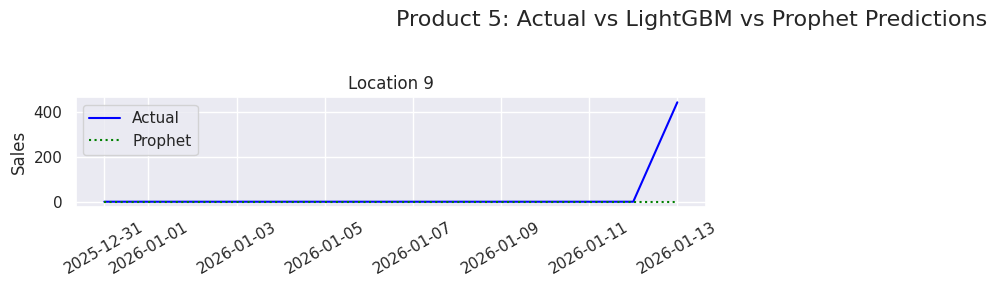

In [181]:
import matplotlib.pyplot as plt
import math

# ----------------------------
# Ensure prediction columns exist
# ----------------------------
if 'predicted' not in test.columns:
    test['predicted'] = None

if 'pred_prophet' not in test.columns:
    test['pred_prophet'] = None

# ----------------------------
# Loop over each product to plot all locations
# ----------------------------
for product_id, prod_group in test.groupby('product_id'):

    locations = prod_group['location_id'].unique()
    n_locs = len(locations)

    # Determine subplot grid
    ncols = 2
    nrows = math.ceil(n_locs / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
    axes = axes.flatten()

    # Plot each location for this product
    for i, loc in enumerate(locations):
        sel = prod_group[prod_group['location_id'] == loc]

        # Actual sales
        axes[i].plot(sel['date'], sel['target'], label='Actual', color='blue')

        # LightGBM predictions
        if sel['predicted'].notna().any():
            axes[i].plot(sel['date'], sel['predicted'], label='LightGBM', color='orange', linestyle='--')

        # Prophet predictions
        if sel['pred_prophet'].notna().any():
            axes[i].plot(sel['date'], sel['pred_prophet'], label='Prophet', color='green', linestyle=':')

        axes[i].set_title(f'Location {loc}')
        axes[i].set_ylabel('Sales')
        axes[i].legend()
        axes[i].grid(True)
        axes[i].tick_params(axis='x', rotation=30)

    # Hide unused subplots if any
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'Product {product_id}: Actual vs LightGBM vs Prophet Predictions', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## 11) Plot forecasts for a sample SKU-location

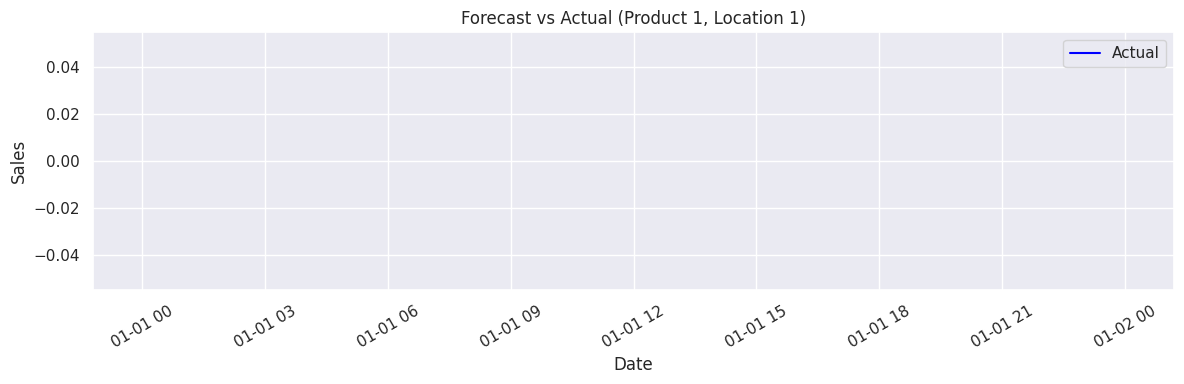

In [182]:
import matplotlib.pyplot as plt

# ----------------------------
# Select a sample: product 1, location 1
# ----------------------------
sample = test[(test['product_id'] == 1) & (test['location_id'] == 1)].copy()

plt.figure(figsize=(12, 4))

# Plot actual sales
plt.plot(sample['date'], sample['target'], label='Actual', color='blue')

# Plot LightGBM predictions if available
if 'predicted' in sample.columns and sample['predicted'].notna().any():
    plt.plot(sample['date'], sample['predicted'], label='LightGBM', color='orange', linestyle='--')

# Plot Prophet predictions if available
if 'pred_prophet' in sample.columns and sample['pred_prophet'].notna().any():
    plt.plot(sample['date'], sample['pred_prophet'], label='Prophet', color='green', linestyle=':')

# Plot ensemble predictions if available
if 'pred_ensemble' in sample.columns and sample['pred_ensemble'].notna().any():
    plt.plot(sample['date'], sample['pred_ensemble'], label='Ensemble', color='red', linestyle='-.')

# Formatting
plt.legend()
plt.xticks(rotation=30)
plt.title('Forecast vs Actual (Product 1, Location 1)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


In [183]:
import joblib
import os

# ----------------------------
# Create models directory if it doesn't exist
# ----------------------------
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# ----------------------------
# Save LightGBM model
# ----------------------------
lgb_model_path = os.path.join(models_dir, 'lgb_model.joblib')
joblib.dump(lgb_model, lgb_model_path)

# ----------------------------
# Save Prophet models (dictionary)
# ----------------------------
prophet_models_path = os.path.join(models_dir, 'prophet_models.joblib')
joblib.dump(prophet_models, prophet_models_path)

print(f"✅ Models saved successfully to '{models_dir}/'")
print(f" - LightGBM: {lgb_model_path}")
print(f" - Prophet models: {prophet_models_path}")

✅ Models saved successfully to 'models/'
 - LightGBM: models/lgb_model.joblib
 - Prophet models: models/prophet_models.joblib


## 12) Save models (LightGBM + Prophet dict)

```python
import joblib
import os

# ----------------------------
# Create models directory if it doesn't exist
# ----------------------------
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# ----------------------------
# Save LightGBM model
# ----------------------------
lgb_model_path = os.path.join(models_dir, 'lgb_model.joblib')
joblib.dump(lgb_model, lgb_model_path)

# ----------------------------
# Save Prophet models (dictionary)
# ----------------------------
prophet_models_path = os.path.join(models_dir, 'prophet_models.joblib')
joblib.dump(prophet_models, prophet_models_path)

print(f"✅ Models saved successfully to '{models_dir}/'")
print(f" - LightGBM: {lgb_model_path}")
print(f" - Prophet models: {prophet_models_path}")
```